In [24]:
#Setup Environment
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
#Load Dataset
df = pd.read_csv(r"C:\Users\AMAN KUMAR  SINGH\ecommerce_data.csv")

In [26]:
df.head()

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,23-12-2023,4,West,No,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,03-04-2025,6,South,No,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,08-10-2024,4,North,No,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,14-09-2024,6,South,No,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,21-12-2024,6,East,No,13.88,2.74,1.15,39,Male


In [27]:
df.shape

(34500, 17)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            34500 non-null  object 
 1   customer_id         34500 non-null  object 
 2   product_id          34500 non-null  object 
 3   category            34500 non-null  object 
 4   price               34500 non-null  float64
 5   discount            34500 non-null  float64
 6   quantity            34500 non-null  int64  
 7   payment_method      34500 non-null  object 
 8   order_date          34500 non-null  object 
 9   delivery_time_days  34500 non-null  int64  
 10  region              34500 non-null  object 
 11  returned            34500 non-null  object 
 12  total_amount        34500 non-null  float64
 13  shipping_cost       34500 non-null  float64
 14  profit_margin       34500 non-null  float64
 15  customer_age        34500 non-null  int64  
 16  cust

In [29]:
df.describe()

,price,discount,quantity,delivery_time_days,total_amount,shipping_cost,profit_margin,customer_age
count,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000
mean,119.391632,0.049291,1.490725,4.814203,170.008494,6.152120,28.116505,43.474377
std,195.620477,0.069894,0.932270,1.242141,357.503014,2.389539,53.352947,14.980682
min,1.010000,0.000000,1.000000,3.000000,0.820000,0.000000,-6.200000,18.000000
25%,16.690000,0.000000,1.000000,4.000000,19.710000,4.420000,1.500000,31.000000
50%,45.660000,0.000000,1.000000,5.000000,56.820000,6.090000,10.550000,43.000000
75%,130.950000,0.100000,2.000000,6.000000,168.530000,7.830000,33.132500,56.000000
max,2930.470000,0.300000,5.000000,13.000000,12931.800000,15.650000,1536.170000,69.000000


In [30]:
df.isnull().sum()

order_id              0
customer_id           0
product_id            0
category              0
price                 0
discount              0
quantity              0
payment_method        0
order_date            0
delivery_time_days    0
region                0
returned              0
total_amount          0
shipping_cost         0
profit_margin         0
customer_age          0
customer_gender       0
dtype: int64

In [31]:
df.columns

Index(['order_id', 'customer_id', 'product_id', 'category', 'price',
       'discount', 'quantity', 'payment_method', 'order_date',
       'delivery_time_days', 'region', 'returned', 'total_amount',
       'shipping_cost', 'profit_margin', 'customer_age', 'customer_gender'],
      dtype='object')

In [32]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['month_name'] = df['order_date'].dt.month_name()
df['day'] = df['order_date'].dt.day

In [33]:
len(df.columns)

21

In [34]:
print(df.duplicated().sum())

0


In [35]:
df['calculated_total'] = df['price'] * (1 - df['discount']) * df['quantity']

In [36]:
df[['total_amount', 'calculated_total']].head()

,total_amount,calculated_total
0,139.47,139.4680
1,24.73,24.7300
2,166.80,166.8010
3,63.67,63.6700
4,13.88,13.8805


In [37]:
loss_orders = df[df['profit_margin'] < 0]
loss_orders.shape

(6104, 22)

In [38]:
#Total Revenue
print(df['total_amount'].sum())

5865293.05


In [39]:
#Revenue by Category
print(df.groupby('category')['total_amount'].sum().sort_values(ascending=False))

category
Electronics    3319206.50
Home           1077681.52
Sports          629825.54
Fashion         471545.80
Beauty          153019.38
Toys            132013.80
Grocery          82000.51
Name: total_amount, dtype: float64


In [40]:
#Profit by Category
df.groupby('category')['profit_margin'].sum().sort_values(ascending=False)

category
Electronics    344371.77
Home           262633.70
Sports         160521.41
Fashion        128814.65
Beauty          49196.59
Toys            33669.25
Grocery         -9187.96
Name: profit_margin, dtype: float64

In [41]:
#Return Rate
df['returned'].value_counts(normalize=True) * 100

returned
No     94.484058
Yes     5.515942
Name: proportion, dtype: float64

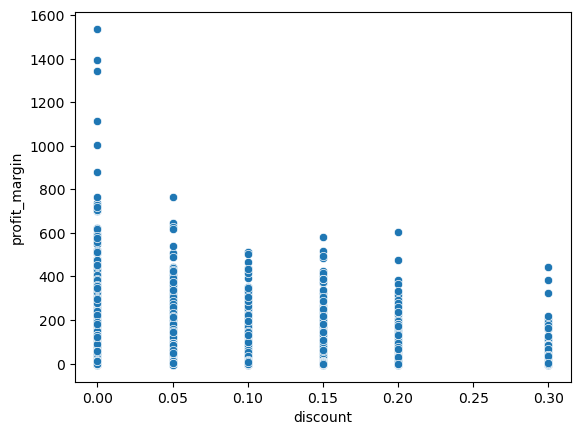

In [42]:
#Discount vs Profit
sns.scatterplot(x='discount', y='profit_margin', data=df)
plt.show()

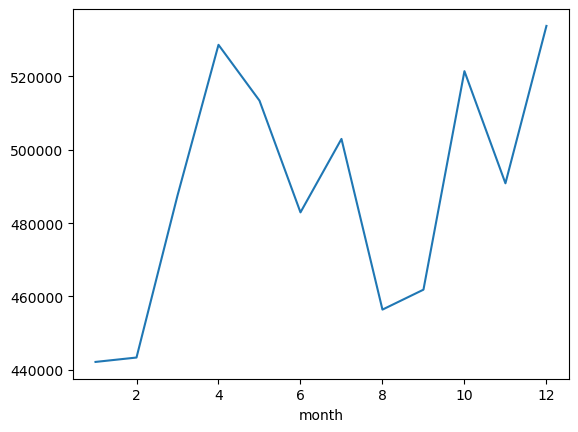

In [43]:
#Monthly Revenue Trend
df.groupby('month')['total_amount'].sum().plot()
plt.show()

In [44]:
#Top Customers
df.groupby('customer_id')['total_amount'].sum().sort_values(ascending=False).head(10)

customer_id
C16655    13885.10
C13565    11984.28
C15379    11375.58
C17116     7424.34
C15644     7244.07
C10975     7209.12
C16382     6973.06
C13767     6546.60
C15254     6509.95
C12427     6480.16
Name: total_amount, dtype: float64

## 📊 Key Insights from E-commerce Transactions Analysis

- **Electronics is the top-performing category**, generating the highest revenue (~₹33.2L), contributing more than half of total sales.

- **Home and Sports categories also contribute significantly**, while Grocery, Toys, and Beauty have comparatively low revenue share.

- **Grocery category is loss-making**, with a total negative profit (~₹9.1K), indicating pricing or cost inefficiencies.

- **Approximately 17.7% of orders (6,104 out of 34,500) are loss-making**, highlighting a major profitability issue.

- **Higher discounts are negatively impacting profit margins**, as observed from the discount vs profit relationship.

- **Overall return rate is low (~5.5%)**, indicating good product quality and customer satisfaction.

- **Revenue is concentrated among a small group of customers**, with top customers contributing significantly higher sales.

- **Monthly sales show fluctuations with peak periods (around April, October, December)**, suggesting seasonal demand trends.

- **Shipping costs and discounts together may be reducing profitability**, especially in low-margin categories.

In [45]:
!pip install pymysql sqlalchemy pandas

In [46]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus
import pandas as pd

username = "root"
password = quote_plus("Herono@1")  
host = "localhost"
port = "3306"
database = "ecommerce_db"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

# Load dataset
df = pd.read_csv(r"C:\Users\AMAN KUMAR  SINGH\ecommerce_data.csv")

# Upload
df.to_sql("ecommerce_data", con=engine, if_exists="replace", index=False)

print("✅ Connected & Data Uploaded Successfully!")

# Verify
print(pd.read_sql("SELECT * FROM ecommerce_data LIMIT 5;", engine))

✅ Connected & Data Uploaded Successfully!
  order_id customer_id product_id     category   price  discount  quantity  \
0  O100000      C17270    P234890         Home  164.08      0.15         1   
1  O100001      C17603    P228204      Grocery   24.73      0.00         1   
2  O100002      C10860    P213892  Electronics  175.58      0.05         1   
3  O100003      C15390    P208689  Electronics   63.67      0.00         1   
4  O100004      C15226    P228063         Home   16.33      0.15         1   

  payment_method  order_date  delivery_time_days region returned  \
0    Credit Card  23-12-2023                   4   West       No   
1    Credit Card  03-04-2025                   6  South       No   
2    Credit Card  08-10-2024                   4  North       No   
3            UPI  14-09-2024                   6  South       No   
4            COD  21-12-2024                   6   East       No   

   total_amount  shipping_cost  profit_margin  customer_age customer_gender  
0 